In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Install these if u are working on local and fresh environment
#python -m pip install --upgrade --force-reinstall torch==2.6.0 tensorflow==2.18.0 keras==3.8.0 tf_keras_vis==0.8.7 transformers==4.57.1 trl==0.24.0 peft==0.17.1 datasets==4.3.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.11.0.86 matplotlib==3.7.2 seaborn==0.12.2 scikit-learn==1.2.2 pillow==11.3.0 tqdm==4.66.4 tf-keras==2.18.0 tornado==6.5.2 evaluate==0.4.6 bitsandbytes==0.48.1

In [3]:
# install these if you are working on kaggle environment
!pip install --upgrade --quiet bitsandbytes datasets evaluate peft tensorboard transformers trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.

In [4]:
import torch, transformers, peft, trl, bitsandbytes, datasets, evaluate, accelerate
import platform, sys

print("="*60)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print("="*60)

print(f"torch version:          {torch.__version__}")
print(f"transformers version:   {transformers.__version__}")
print(f"peft version:           {peft.__version__}")
print(f"trl version:            {trl.__version__}")
print(f"bitsandbytes version:   {bitsandbytes.__version__}")
print(f"datasets version:       {datasets.__version__}")
print(f"evaluate version:       {evaluate.__version__}")
print(f"accelerate version:     {accelerate.__version__}")
print("="*60)

# Check GPU availability and configuration
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
print("="*60)

2025-11-01 19:10:52.674433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762024252.853425      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762024252.908039      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
Platform: Linux-6.6.56+-x86_64-with-glibc2.35
torch version:          2.6.0+cu124
transformers version:   4.57.1
peft version:           0.17.1
trl version:            0.24.0
bitsandbytes version:   0.48.2
datasets version:       4.3.0
evaluate version:       0.4.6
accelerate version:     1.9.0
CUDA available: True
GPU count: 1
GPU name: Tesla T4
CUDA capability: (7, 5)


In [5]:
import os, gc, math, warnings
warnings.filterwarnings("ignore")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import torch
from peft import LoraConfig, PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from tqdm import tqdm
import pickle
import google.generativeai as genai 
import time

In [6]:
# ---------------- USER CONFIG  ----------------
LOCAL_DIR = "/kaggle/input/med-gemma-4b/gemmacpp/default/1/google_medgemma_4b_it"
CSV_PATH  = "/kaggle/input/skincancergradcamexplanationdataset/gradcam_dataset/Proposed_Dataset_explanations.csv"
HEATMAP_DIR = "/kaggle/input/skincancergradcamexplanationdataset/gradcam_dataset/gradcam"
FULL_MODEL_DIR = "/kaggle/working/medgemma4b_finetuned_skin_xai"
LORA_OUTPUT_DIR = "./medgemma_lora_adapter"
TRAIN_OUTPUT_DIR = "MedGemma-4B-IT-SkinXAI"   # trainer outputs
USE_4BIT = True                               # keep 4-bit quant to fit T4
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# training hyperparams 
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE  = 1
GRADIENT_ACCUMULATION_STEPS = 4
NUM_TRAIN_EPOCHS = 3
LEARNING_RATE = 2e-4
R_LORA = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

print(f"DEVICE={DEVICE} | USE_4BIT={USE_4BIT}")

DEVICE=cuda:0 | USE_4BIT=True


In [7]:
"""
# mapping the short class names to full names in the CSV 
# Skip this step if dataset has full name already 
df = pd.read_csv(CSV_PATH)
ham10000_map = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "vasc": "Vascular lesions"
}

df["predicted_class"] = df["predicted_class"].map(ham10000_map)

#update it to save in working dir
CSV_PATH = "Proposed_Final_Dataset.csv"
df.to_csv(CSV_PATH, index=False)

print("Mapping complete! File updated in place:", CSV_PATH)
print(df.head())
"""

'\n# mapping the short class names to full names in the CSV \n# Skip this step if dataset has full name already \ndf = pd.read_csv(CSV_PATH)\nham10000_map = {\n    "akiec": "Actinic keratoses and intraepithelial carcinoma",\n    "bcc": "Basal cell carcinoma",\n    "bkl": "Benign keratosis-like lesions",\n    "df": "Dermatofibroma",\n    "nv": "Melanocytic nevi",\n    "mel": "Melanoma",\n    "vasc": "Vascular lesions"\n}\n\ndf["predicted_class"] = df["predicted_class"].map(ham10000_map)\n\n#update it to save in working dir\nCSV_PATH = "Proposed_Final_Dataset.csv"\ndf.to_csv(CSV_PATH, index=False)\n\nprint("Mapping complete! File updated in place:", CSV_PATH)\nprint(df.head())\n'

In [8]:
# ---------------- Build HF dataset ----------------
def get_filename(path):
    if path is None: return ""
    p = str(path).strip().replace("\\","/")
    return p.split("/")[-1].strip()

df = pd.read_csv(CSV_PATH, encoding='cp1252')
instruction_template = (
    "You are an AI assistant specialized in model interpretability. "
    "I am providing:\n- CNN model Grad-CAM++ heatmap image\n- Model predicted class: {predicted_class}\n\n"
    "Based on the Grad-CAM++ heatmap, write a clear and concise 20–30 word explanation "
    "of which features the model focused on and why. Output only the explanation (no headings)."
)

dataset_list = []
for _, row in df.iterrows():
    img_name = get_filename(row["gradcam_image"])
    img_path = os.path.join(HEATMAP_DIR, img_name)
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Missing image: {img_path}")
    img = Image.open(img_path).convert("RGB").resize((224,224), Image.BILINEAR)
    conv = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image"
                },
                {
                    "type": "text",
                    "text": instruction_template.format(predicted_class=row["predicted_class"])
                }
            ]
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": row["gradcam_description"]
                }
            ]
        }
    ]

    dataset_list.append({"image": img, "messages": conv})

hf_dataset = Dataset.from_list(dataset_list)
print("Total rows:", len(hf_dataset))

Total rows: 347


In [9]:
# split 90/10
split = hf_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset  = split["test"]
print("Train/Val sizes:", len(train_dataset), len(eval_dataset))

Train/Val sizes: 312 35


In [10]:
# ---------------- Load processor & base model MATCHING YOUR ORIGINAL SNIPPET ----------------
# Choose dtype exactly like your original code:
capability = torch.cuda.get_device_capability(0)[0] if torch.cuda.is_available() else 0
dtype = torch.bfloat16 if torch.cuda.is_available() and capability >= 8 else torch.float32
bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=dtype,
    )

print("Loading model with dtype:", dtype)
processor = AutoProcessor.from_pretrained(LOCAL_DIR, local_files_only=True, trust_remote_code=True)
processor.tokenizer.padding_side = "right"

model = AutoModelForImageTextToText.from_pretrained(
    LOCAL_DIR,
    quantization_config=bnb_config if USE_4BIT else None,
    dtype=dtype,                # important: match what you used earlier
    device_map="auto",
    local_files_only=True,
    trust_remote_code=True
)

print("Base model loaded.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading model with dtype: torch.float32


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Base model loaded.


In [11]:
# ---------------- PRE-FINETUNE SANITY CHECK ----------------
print("=== PRE-FINETUNE SANITY CHECK ===")
# move model to device if possible 
try:
    model.to(DEVICE)
except Exception:
    # model may be sharded by device_map='auto'; keep as is
    pass

example = dataset_list[0]
image = example["image"].convert("RGB") 
user_prompt = example["messages"][0]["content"][1]["text"]
chat = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt}
        ],
    }
]
formatted_prompt = processor.apply_chat_template(
    chat, add_generation_prompt=True, tokenize=False
)

inputs = processor(
    text=formatted_prompt,
    images=image,
    return_tensors="pt",
    padding=True
)

# move inputs to device if possible
try:
    inputs = inputs.to(DEVICE)
except Exception:
    for k,v in inputs.items():
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(DEVICE)

if hasattr(inputs, "pixel_values") and inputs.pixel_values is not None:
    # match pixel dtype to model dtype if possible
    try:
        inputs.pixel_values = inputs.pixel_values.to(dtype=model.dtype)
    except Exception:
        inputs.pixel_values = inputs.pixel_values.to(dtype=torch.float16)

input_ids_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False,        
        pad_token_id=processor.tokenizer.eos_token_id,
        temperature=1.0,
        top_p=0.9,
    )
# if output_ids is a tensor; handle both
if hasattr(output_ids, "sequences"):
    seqs = output_ids.sequences
else:
    seqs = output_ids

response = processor.decode(seqs[0, input_ids_len:], skip_special_tokens=True)
print("PRE-FINETUNE Model Prediction: \n")
print(response)

The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== PRE-FINETUNE SANITY CHECK ===
PRE-FINETUNE Model Prediction: 

The model focused on the central, reddish-orange area with surrounding skin structures, likely highlighting the lesion's color and texture as key features for classification.



In [12]:
# ====== Run pre fine tune inference and store results ======
pre_finetune_results = []

for example in tqdm(eval_dataset, desc="Generating model responses..."):
    try:
        image = example["image"].convert("RGB")
        user_prompt = example["messages"][0]["content"][1]["text"]
        true_response = example["messages"][1]["content"][0]["text"]

        chat = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": user_prompt}
                ],
            }
        ]

        formatted_prompt = processor.apply_chat_template(
            chat, add_generation_prompt=True, tokenize=False
        )

        inputs = processor(
            text=formatted_prompt,
            images=image,
            return_tensors="pt",
            padding=True
        )

        # Move inputs to device
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor):
                inputs[k] = v.to(DEVICE)

        if hasattr(inputs, "pixel_values"):
            try:
                inputs.pixel_values = inputs.pixel_values.to(dtype=model.dtype)
            except Exception:
                inputs.pixel_values = inputs.pixel_values.to(torch.float16)

        input_ids_len = inputs["input_ids"].shape[-1]

        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,
                pad_token_id=processor.tokenizer.eos_token_id,
                #temperature=1.0,
                #top_p=0.9,
            )

        seqs = output_ids.sequences if hasattr(output_ids, "sequences") else output_ids
        gen_response = processor.decode(seqs[0, input_ids_len:], skip_special_tokens=True)

        pre_finetune_results.append({
            "image": image,
            "prompt": user_prompt,
            "model_response": gen_response,
            "true_response": true_response
        })

    except Exception as e:
        print(f"Error processing sample: {e}")

with open("pre_finetune_eval_predictions.pkl", "wb") as f:
    pickle.dump(pre_finetune_results, f)

print("Saved eval predictions to pre_finetune_eval_predictions.pkl")

Generating model responses...: 100%|██████████| 35/35 [03:44<00:00,  6.41s/it]

Saved eval predictions to pre_finetune_eval_predictions.pkl


In [13]:
# ---------------- Collate function for training (ONLY mask known sentinel + optional boi_token) ----------------
mask_token_ids = {262144}  # known sentinel used by this processor/model
try:
    boi_tok = processor.tokenizer.special_tokens_map.get("boi_token", None)
    if boi_tok is not None:
        boi_id = processor.tokenizer.convert_tokens_to_ids(boi_tok)
        if boi_id is not None:
            mask_token_ids.add(boi_id)
except Exception:
    pass

print("Masking token ids (training):", mask_token_ids)

Masking token ids (training): {262144, 255999}


In [14]:
"""
def collate_fn(examples):
    texts, images = [], []
    for ex in examples:
        texts.append(processor.apply_chat_template(ex["messages"], add_generation_prompt=False, tokenize=False).strip())
        images.append([ex["image"].convert("RGB")])
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()
    pad_id = processor.tokenizer.pad_token_id
    labels[labels == pad_id] = -100
    for tid in mask_token_ids:
        labels[labels == tid] = -100
    non_mask = (labels != -100).sum().item()
    total = labels.numel()
    #print(f"collate_fn: non-masked-labels {non_mask}/{total} = {non_mask/total:.4f}")
    batch["labels"] = labels
    return batch

col = collate_fn([dataset_list[0]])
"""

'\ndef collate_fn(examples):\n    texts, images = [], []\n    for ex in examples:\n        texts.append(processor.apply_chat_template(ex["messages"], add_generation_prompt=False, tokenize=False).strip())\n        images.append([ex["image"].convert("RGB")])\n    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)\n    labels = batch["input_ids"].clone()\n    pad_id = processor.tokenizer.pad_token_id\n    labels[labels == pad_id] = -100\n    for tid in mask_token_ids:\n        labels[labels == tid] = -100\n    non_mask = (labels != -100).sum().item()\n    total = labels.numel()\n    #print(f"collate_fn: non-masked-labels {non_mask}/{total} = {non_mask/total:.4f}")\n    batch["labels"] = labels\n    return batch\n\ncol = collate_fn([dataset_list[0]])\n'

In [15]:
def collate_fn(examples):
    texts = [processor.apply_chat_template(ex["messages"], add_generation_prompt=True, tokenize=False).strip() for ex in examples]
    images = [[ex["image"].convert("RGB")] for ex in examples]
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    pad_id = processor.tokenizer.pad_token_id
    labels[labels == pad_id] = -100

    # Attempt to find generation start token per sample:
    # 1) prefer a known sentinel if present in tokenizer special tokens
    sentinel_ids = []
    # try common options
    for key in ("boi_token","gen_token","assistant_token","response_token"):
        token = processor.tokenizer.special_tokens_map.get(key, None)
        if token:
            tid = processor.tokenizer.convert_tokens_to_ids(token)
            if isinstance(tid, int):
                sentinel_ids.append(tid)
    # fallback: try tokenizer.eos_token_id as a heuristic
    fallback = processor.tokenizer.eos_token_id

    for i in range(labels.size(0)):
        seq = batch["input_ids"][i]
        # find first sentinel occurrence
        pos = None
        for sid in sentinel_ids:
            locs = (seq == sid).nonzero(as_tuple=True)[0]
            if len(locs) > 0:
                pos = locs[0].item()
                break
        if pos is None:
            # fallback to first eos token occurrence
            locs = (seq == fallback).nonzero(as_tuple=True)[0]
            pos = locs[0].item() if len(locs) > 0 else 0

        # mask everything up to and including the sentinel (so only assistant gen is learned)
        labels[i, : pos+1] = -100

    # also mask any other user/prompt sentinel tokens if you used them:
    for tid in mask_token_ids:
        labels[labels == tid] = -100

    batch["labels"] = labels
    return batch

In [16]:
# Inspect label tokens for sanity 
from typing import List

def inspect_label_tokens(sample_index: int = 0, max_tokens: int | None = None):
    """
    Print non-masked label tokens for one sample (by default sample_index=0).
    Shows: position_in_sequence, token_id, token_str, decoded_text_for_token.
    max_tokens: if set, limits how many tokens to print (first N non-masked tokens).
    """
    # Build a collated batch for the single sample to get labels
    collated = collate_fn([dataset_list[sample_index]])
    labels = collated["labels"][0].cpu().numpy().tolist()  # list of ints (with -100 masked)
    input_ids = collated["input_ids"][0].cpu().numpy().tolist()
    attention = collated["attention_mask"][0].cpu().numpy().tolist()

    # Full decoded prompt 
    try:
        full_decoded = processor.tokenizer.decode([tid for tid in input_ids if tid != processor.tokenizer.pad_token_id], skip_special_tokens=False)
    except Exception:
        full_decoded = "<cannot decode full input_ids>"

    print(f"\n--- Sample {sample_index} context (decoded input_ids, not skipping special tokens) ---")
    print(full_decoded)
    print("\nIndex | token_id | token_str | decoded_piece")
    print("-"*60)

    non_mask_positions: List[int] = [i for i, t in enumerate(labels) if t != -100]

    if len(non_mask_positions) == 0:
        print("No non-masked labels found (all -100).")
        return

    if max_tokens is not None:
        non_mask_positions = non_mask_positions[:max_tokens]

    for pos in non_mask_positions:
        tid = labels[pos]
        # token string (may be special or sentinel)
        try:
            token_str = processor.tokenizer.convert_ids_to_tokens(int(tid))
        except Exception:
            token_str = "<unk-token-conversion-error>"
        # decoded text for this single token (sometimes it's a partial subword)
        try:
            decoded_piece = processor.tokenizer.decode([int(tid)], skip_special_tokens=True)
        except Exception:
            decoded_piece = "<cannot-decode-token>"
        print(f"{pos:4d} | {tid:7d} | {token_str:20s} | {decoded_piece}")

#inspect first sample and print all non-masked tokens
inspect_label_tokens(sample_index=0, max_tokens=None)


--- Sample 0 context (decoded input_ids, not skipping special tokens) ---
<bos><bos><start_of_turn>user


<start_of_image><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_t

In [17]:
# ---------------- LoRA config & SFTTrainer config (trainer will wrap model) ----------------
peft_config = LoraConfig(
    r=R_LORA, lora_alpha=LORA_ALPHA,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=LORA_DROPOUT, 
    bias="none", 
    task_type="CAUSAL_LM"
)

sft_args = SFTConfig(
    output_dir=TRAIN_OUTPUT_DIR,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    learning_rate=LEARNING_RATE,
    bf16=False,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=10,
    report_to="tensorboard",
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},
    #max_steps=3     # This will overwrite the no of epoch,
)

num_samples = len(train_dataset)
effective_batch = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
print(f"Expected optimizer steps per epoch (approx): ceil({num_samples}/{effective_batch}) = {math.ceil(num_samples/effective_batch)}")


Expected optimizer steps per epoch (approx): ceil(312/4) = 78


In [18]:
trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,        # trainer wraps with LoRA
    processing_class=processor,
    data_collator=collate_fn,
)

trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"Trainable {trainable:,} / Total {total:,}")

Trainable 16,394,240 / Total 2,506,617,200


In [19]:
# ---------------- TRAIN ----------------
print("\n=== START LoRA TRAINING ===")
trainer.train()
print("Training complete.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.



=== START LoRA TRAINING ===


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.215800,0.838691,5.476912,15422.000000,0.842360
20,0.676800,0.615724,5.702660,30844.000000,0.865041
30,0.570700,0.536754,5.017455,46288.000000,0.873378
40,0.472300,0.460903,2.118753,61711.000000,0.886972
50,0.431000,0.423211,1.464943,77095.000000,0.891997
60,0.408300,0.401910,1.040911,92514.000000,0.895315
70,0.380300,0.383639,0.853712,107900.000000,0.899198
80,0.399100,0.380713,1.037869,123396.000000,0.895858
90,0.332200,0.375016,1.106857,138843.000000,0.900047
100,0.318200,0.369140,1.297113,154292.000000,0.900710


Training complete.


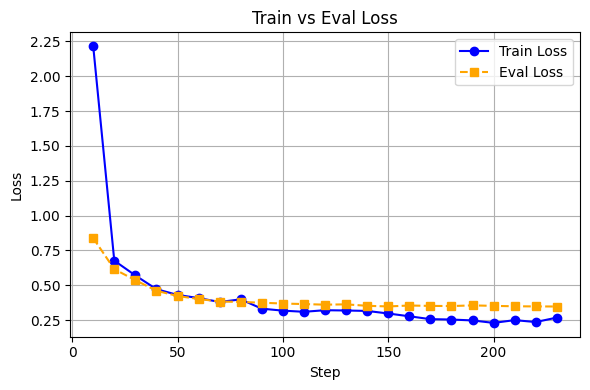

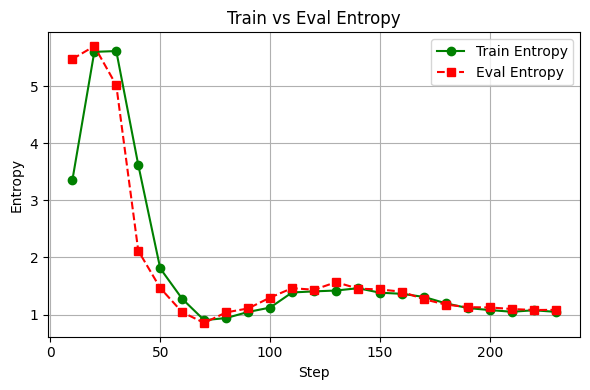

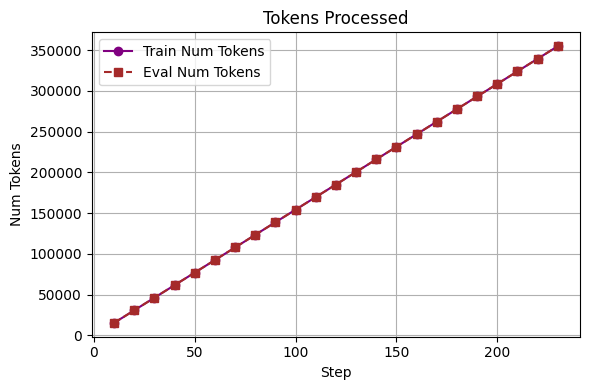

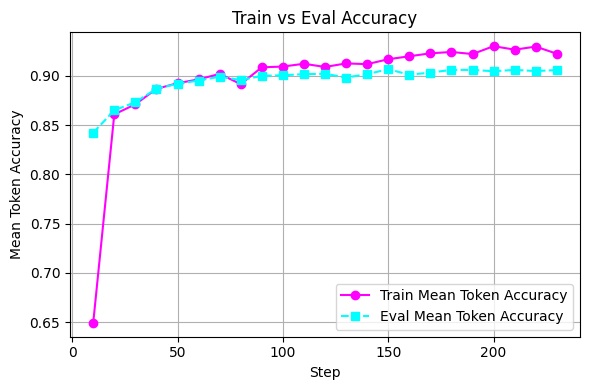

In [20]:
# --- Save training logs ---
logs = trainer.state.log_history
log_file = "training_logs.json"

with open(log_file, "w") as f:
    json.dump(logs, f, indent=4)

try:
    # --- Extract train and eval metrics safely ---
    train_steps    = [log['step'] for log in logs if 'loss' in log]
    train_loss     = [log['loss'] for log in logs if 'loss' in log]
    train_entropy  = [log['entropy'] for log in logs if 'entropy' in log]
    train_tokens   = [log['num_tokens'] for log in logs if 'num_tokens' in log]
    train_acc      = [log['mean_token_accuracy'] for log in logs if 'mean_token_accuracy' in log]

    eval_steps     = [log['step'] for log in logs if 'eval_loss' in log]
    eval_loss      = [log['eval_loss'] for log in logs if 'eval_loss' in log]
    eval_entropy   = [log['eval_entropy'] for log in logs if 'eval_entropy' in log]
    eval_tokens    = [log['eval_num_tokens'] for log in logs if 'eval_num_tokens' in log]
    eval_acc       = [log['eval_mean_token_accuracy'] for log in logs if 'eval_mean_token_accuracy' in log]

    import matplotlib.pyplot as plt

    # --- Plot helper that handles mismatched or missing data safely ---
    def plot_metric(train_steps, train_vals, eval_steps, eval_vals, ylabel, title,
                    train_color='blue', eval_color='orange'):
        plt.figure(figsize=(6, 4))

        # --- Handle mismatched lengths safely ---
        def safe_trim(x, y):
            n = min(len(x), len(y))
            return x[:n], y[:n]

        if len(train_steps) > 0 and len(train_vals) > 0:
            ts, tv = safe_trim(train_steps, train_vals)
            plt.plot(ts, tv, '-o', label=f'Train {ylabel}', color=train_color)

        if len(eval_steps) > 0 and len(eval_vals) > 0:
            es, ev = safe_trim(eval_steps, eval_vals)
            plt.plot(es, ev, '--s', label=f'Eval {ylabel}', color=eval_color)

        plt.xlabel('Step')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # --- Plot all metrics safely ---
    plot_metric(train_steps, train_loss, eval_steps, eval_loss, 'Loss', 'Train vs Eval Loss')
    plot_metric(train_steps, train_entropy, eval_steps, eval_entropy, 'Entropy', 'Train vs Eval Entropy',
                'green', 'red')
    plot_metric(train_steps, train_tokens, eval_steps, eval_tokens, 'Num Tokens', 'Tokens Processed',
                'purple', 'brown')
    plot_metric(train_steps, train_acc, eval_steps, eval_acc, 'Mean Token Accuracy', 'Train vs Eval Accuracy',
                'magenta', 'cyan')

except Exception as e:
    print("⚠️ Error while plotting logs:", e)


In [21]:
print("LoRA adapter and processor saving to disk....")
trainer.model.save_pretrained(LORA_OUTPUT_DIR)  
processor.save_pretrained(LORA_OUTPUT_DIR)
print("LoRA adapter + processor saved to:", LORA_OUTPUT_DIR)

import os
print(os.listdir(LORA_OUTPUT_DIR)) #checking if saved or not

LoRA adapter and processor saving to disk....
LoRA adapter + processor saved to: ./medgemma_lora_adapter
['special_tokens_map.json', 'tokenizer_config.json', 'adapter_model.safetensors', 'adapter_config.json', 'preprocessor_config.json', 'tokenizer.json', 'added_tokens.json', 'chat_template.jinja', 'tokenizer.model', 'processor_config.json', 'README.md']


> Independent code for loading model from disk and inferring

In [22]:
import torch
from torch import nn
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText
)
from peft import PeftModel
from peft import LoraConfig
from transformers import BitsAndBytesConfig  
from PIL import Image
import os
from tqdm import tqdm 
import pickle 

> Loading both model and adapter from disk (no internet connection required)

In [23]:
# load base with same quantization config and attach LoRA adapter
USE_4BIT = True              
LOCAL_DIR = r"/kaggle/input/med-gemma-4b/gemmacpp/default/1/google_medgemma_4b_it" 
LORA_OUTPUT_DIR = r"medgemma_lora_adapter"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE={DEVICE} | USE_4BIT={USE_4BIT}")

# bfloat16 if capability >=8 else float32
capability = torch.cuda.get_device_capability(0)[0] if torch.cuda.is_available() else 0
dtype = torch.bfloat16 if torch.cuda.is_available() and capability >= 8 else torch.float32
print("Loading model with dtype:", dtype)
bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=dtype,
    )

print("Processor loading...")
processor = AutoProcessor.from_pretrained(
    LORA_OUTPUT_DIR, 
    local_files_only=True, 
    trust_remote_code=True
)
processor.tokenizer.padding_side = "right"

print("Base model loading....")
base_model = AutoModelForImageTextToText.from_pretrained(
    LOCAL_DIR,
    quantization_config=bnb_config if USE_4BIT else None,
    dtype=dtype,
    device_map="auto",
    local_files_only=True,
    trust_remote_code=True,
)

print("Adding LoRa adapter from base model")
model = PeftModel.from_pretrained(
    base_model, 
    LORA_OUTPUT_DIR, 
    device_map="auto"
)
model.eval() 
print("Loaded base + LoRA. Ready for inference on", DEVICE)


DEVICE=cuda | USE_4BIT=True
Loading model with dtype: torch.float32
Processor loading...
Base model loading....


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Adding LoRa adapter from base model
Loaded base + LoRA. Ready for inference on cuda


> Below code only need lora adapter disk path for full model loading as it downloading base model from huggingface repo (Internet Connection Required)

In [ ]:
"""
USE_4BIT = True              
HF_MODEL_ID = "google/medgemma-4b-it"  # Hugging Face repo ID
LORA_OUTPUT_DIR = "./medgemma_lora_adapter" #local lora saved dir
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
hf_token =  "hidden" #NOTE: hiding mandatory (reminder)

# Determine dtype
capability = torch.cuda.get_device_capability(0)[0] if torch.cuda.is_available() else 0
dtype = torch.bfloat16 if torch.cuda.is_available() and capability >= 8 else torch.float32

# 4-bit quantization config
bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=dtype,
    )

# Load processor from LoRA adapter folder (it contains tokenizer, etc.)
print("Processor loading...")
processor = AutoProcessor.from_pretrained(
    LORA_OUTPUT_DIR, 
    trust_remote_code=True
)
processor.tokenizer.padding_side = "right"

# Load base model from Hugging Face hub
print("Base model loading from Hugging Face hub...")
base_model = AutoModelForImageTextToText.from_pretrained(
    HF_MODEL_ID,
    quantization_config=bnb_config if USE_4BIT else None,
    dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    use_auth_token=hf_token  # only needed if repo is private
)

# Attach LoRA adapter
print("Attaching LoRA adapter from local folder...")
model = PeftModel.from_pretrained(
    base_model,
    LORA_OUTPUT_DIR,
    device_map="auto"
)

model.eval()
print("Loaded base + LoRA. Ready for inference on", DEVICE)
"""

'\nUSE_4BIT = True              \nHF_MODEL_ID = "google/medgemma-4b-it"  # Hugging Face repo ID\nLORA_OUTPUT_DIR = "./medgemma_lora_adapter" #local lora saved dir\nDEVICE = "cuda" if torch.cuda.is_available() else "cpu"\nhf_token = "hidden" #NOTE: hiding mandatory (reminder)\n\n# Determine dtype\ncapability = torch.cuda.get_device_capability(0)[0] if torch.cuda.is_available() else 0\ndtype = torch.bfloat16 if torch.cuda.is_available() and capability >= 8 else torch.float32\n\n# 4-bit quantization config\nbnb_config = None\nif USE_4BIT:\n    bnb_config = BitsAndBytesConfig(\n        load_in_4bit=True,\n        bnb_4bit_use_double_quant=True,\n        bnb_4bit_quant_type="nf4",\n        bnb_4bit_compute_dtype=dtype,\n    )\n\n# Load processor from LoRA adapter folder (it contains tokenizer, etc.)\nprint("Processor loading...")\nprocessor = AutoProcessor.from_pretrained(\n    LORA_OUTPUT_DIR, \n    trust_remote_code=True\n)\nprocessor.tokenizer.padding_side = "right"\n\n# Load base model 

In [25]:
# ---------------- POST-FINETUNE---------------
print("=== POST-FINETUNE SANITY CHECK  ===")
try:
    model.to(DEVICE)
except Exception:
    pass

image_path = "/kaggle/input/skincancergradcamexplanationdataset/gradcam_dataset/gradcam/ISIC_0024330.jpg"
image = Image.open(image_path).convert("RGB")
image = image.resize((224, 224), Image.BILINEAR)
prompt_template = (
    "You are an AI assistant specialized in model interpretability. "
    "I am providing:\n- CNN model Grad-CAM++ heatmap image\n- Model predicted class: {predicted_class}\n\n"
    "Based on the Grad-CAM++ heatmap, write a clear and concise 20–30 word explanation "
    "of which features the model focused on and why. Output only the explanation (no headings)."
)
user_prompt=prompt_template.format(predicted_class="df")

chat = [
    {
        "role": "user",
        "content": [
            {
                "type": "image"
            },
            {
                "type": "text", 
                "text": user_prompt
            }
        ],
    }
]
formatted_prompt = processor.apply_chat_template(
    chat, add_generation_prompt=True, tokenize=False
)
inputs = processor(
    text=formatted_prompt,
    images=image,
    return_tensors="pt",
    padding=True
)
try:
    inputs = inputs.to(DEVICE)
except Exception:
    for k,v in inputs.items():
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(DEVICE)

if hasattr(inputs, "pixel_values") and inputs.pixel_values is not None:
    try:
        inputs.pixel_values = inputs.pixel_values.to(dtype=model.dtype)
    except Exception:
        inputs.pixel_values = inputs.pixel_values.to(dtype=torch.float16)

input_ids_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=processor.tokenizer.eos_token_id,
        #temperature=0.9,
        #top_p=0.9,
    )

if hasattr(output_ids, "sequences"):
    seqs = output_ids.sequences
else:
    seqs = output_ids

response = processor.decode(seqs[0, input_ids_len:], skip_special_tokens=True)
print("POST-FINETUNE Model Prediction: \n")
print(response)

=== POST-FINETUNE SANITY CHECK  ===
POST-FINETUNE Model Prediction: 

The model focused on the central reddish-pink, textured area, likely identifying features like vascularity and structural irregularity characteristic of a dermatofibroma.


In [26]:
# ====== Run fine tune inference and store results ======
finetune_results = []

for example in tqdm(eval_dataset, desc="Generating model responses..."):
    try:
        image = example["image"].convert("RGB")
        user_prompt = example["messages"][0]["content"][1]["text"]
        true_response = example["messages"][1]["content"][0]["text"]

        chat = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": user_prompt}
                ],
            }
        ]

        formatted_prompt = processor.apply_chat_template(
            chat, add_generation_prompt=True, tokenize=False
        )

        inputs = processor(
            text=formatted_prompt,
            images=image,
            return_tensors="pt",
            padding=True
        )

        # Move inputs to device
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor):
                inputs[k] = v.to(DEVICE)

        if hasattr(inputs, "pixel_values"):
            try:
                inputs.pixel_values = inputs.pixel_values.to(dtype=model.dtype)
            except Exception:
                inputs.pixel_values = inputs.pixel_values.to(torch.float16)

        input_ids_len = inputs["input_ids"].shape[-1]

        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,
                pad_token_id=processor.tokenizer.eos_token_id,
                #temperature=1.0,
                #top_p=0.9,
            )

        seqs = output_ids.sequences if hasattr(output_ids, "sequences") else output_ids
        gen_response = processor.decode(seqs[0, input_ids_len:], skip_special_tokens=True)

        finetune_results.append({
            "image": image,
            "prompt": user_prompt,
            "model_response": gen_response,
            "true_response": true_response
        })

    except Exception as e:
        print(f"Error processing sample: {e}")

with open("finetune_eval_predictions.pkl", "wb") as f:
    pickle.dump(finetune_results, f)

print("Saved fine-tuned model eval predictions to finetune_eval_predictions.pkl")

Generating model responses...: 100%|██████████| 35/35 [04:59<00:00,  8.55s/it]

Saved fine-tuned model eval predictions to finetune_eval_predictions.pkl
